# Fine-tuning Grounding DINO on BCCD blood cells

Before/after comparison of zero-shot vs fine-tuned Grounding DINO on the
[BCCD dataset](https://github.com/Shenggan/BCCD_Dataset) (364 blood smear
images; RBC, WBC, Platelets).

**Note on the source script.** `Video05_finetune_gdino_v2.py` is a PyQt5
desktop GUI and cannot run in Colab — there is no display, so `QApplication`
fails. It does have an `if __name__ == "__main__"` guard, so this notebook
**imports it and calls its real functions** (`GDINODataset`,
`compute_gdino_loss`, `collate_fn`). The training maths is the author's; only
the Qt shell is replaced.

**Why BCCD.** Zero-shot Grounding DINO handles "white blood cell" reasonably
(it resembles web-caption language) but is near-blind to platelets. That gives
a control class and a class that should actually move.

**Set Runtime → Change runtime type → T4 GPU before running.**

## 1. Install dependencies

In [ ]:
!pip install -q transformers accelerate timm PyQt5 matplotlib
print("done")

done


## 2. Fetch the fine-tuning script and the dataset

`QT_QPA_PLATFORM=offscreen` lets PyQt5 import without a display.

In [ ]:
import os
os.environ["QT_QPA_PLATFORM"] = "offscreen"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"  # reduces fragmentation

!wget -q https://raw.githubusercontent.com/bnsreenu/llm-vision-for-scientists/main/Video05_finetune_gdino_v2.py
!git clone -q https://github.com/Shenggan/BCCD_Dataset.git

import pathlib
print("script:", pathlib.Path("Video05_finetune_gdino_v2.py").exists())
print("images:", len(list(pathlib.Path("BCCD_Dataset/BCCD/JPEGImages").glob("*.jpg"))))

fatal: destination path 'BCCD_Dataset' already exists and is not an empty directory.
script: True
images: 364


## 3. Write the converter module

BCCD ships as Pascal VOC XML. `GDINODataset` needs COCO JSON with two
non-standard properties: `file_name` must be a **full path** (it calls
`Image.open(file_name)` with no image root), and each category needs a
`phrases` list used to build the text prompt. The synonyms below matter a
lot — "platelet" alone gives the text encoder almost nothing visual.

In [ ]:
%%writefile bccd_to_coco.py
"""
bccd_to_coco.py — BCCD (Pascal VOC XML) -> the COCO variant that
Video05_finetune_gdino_v2.py expects.

BCCD ships as 364 JPEGs + 364 VOC XML files, with official train/val/test
lists in BCCD/ImageSets/Main/. Classes: RBC, WBC, Platelets.

Produces absolute file_name paths and a "phrases" list per category, which
is what GDINODataset requires.
"""

import json
import xml.etree.ElementTree as ET
from collections import defaultdict
from pathlib import Path

# Synonyms matter more than anything else here. Grounding DINO grounds on
# natural language, so "platelet" alone gives it almost nothing to work with,
# while a descriptive phrase gives the text encoder something visual to attach.
BCCD_PHRASES = {
    "RBC":       ["red blood cell"],
    "WBC":       ["white blood cell"],
    "Platelets": ["platelet"],
}

CATEGORY_ORDER = ["RBC", "WBC", "Platelets"]   # ids 1, 2, 3


def _read_split(bccd_root, split):
    f = Path(bccd_root) / "ImageSets" / "Main" / f"{split}.txt"
    return [ln.strip() for ln in f.read_text().splitlines() if ln.strip()]


def _parse_xml(xml_path):
    root = ET.parse(xml_path).getroot()
    size = root.find("size")
    w = int(size.find("width").text)
    h = int(size.find("height").text)
    objs = []
    for obj in root.findall("object"):
        name = obj.find("name").text.strip()
        bb = obj.find("bndbox")
        x1 = float(bb.find("xmin").text)
        y1 = float(bb.find("ymin").text)
        x2 = float(bb.find("xmax").text)
        y2 = float(bb.find("ymax").text)
        # A handful of VOC files in the wild have flipped or out-of-range
        # coords; clamp rather than trusting them.
        x1, x2 = sorted((max(0, x1), min(w, x2)))
        y1, y2 = sorted((max(0, y1), min(h, y2)))
        if x2 - x1 < 2 or y2 - y1 < 2:
            continue
        objs.append((name, [x1, y1, x2 - x1, y2 - y1]))
    return w, h, objs


def build_split(bccd_root, split, classes=None, verbose=True):
    """classes: subset of CATEGORY_ORDER to keep. None = all three."""
    bccd_root = Path(bccd_root).resolve()
    keep = classes or CATEGORY_ORDER
    cat_id = {name: i for i, name in enumerate(keep, start=1)}

    ids = _read_split(bccd_root, split)
    images, annotations = [], []
    ann_id = 1
    skipped_missing = 0

    for i, stem in enumerate(ids, start=1):
        jpg = bccd_root / "JPEGImages" / f"{stem}.jpg"
        xml = bccd_root / "Annotations" / f"{stem}.xml"
        if not jpg.exists() or not xml.exists():
            skipped_missing += 1
            continue
        w, h, objs = _parse_xml(xml)
        objs = [(n, b) for n, b in objs if n in cat_id]
        if not objs:
            continue                      # fine-tuner drops these anyway
        images.append({"id": i, "file_name": str(jpg), "width": w, "height": h})
        for name, bbox in objs:
            annotations.append({
                "id": ann_id, "image_id": i, "category_id": cat_id[name],
                "bbox": bbox, "area": bbox[2] * bbox[3], "iscrowd": 0,
            })
            ann_id += 1

    coco = {
        "images": images,
        "annotations": annotations,
        "categories": [
            {"id": cat_id[n], "name": n, "supercategory": "cell",
             "phrases": BCCD_PHRASES[n]}
            for n in keep
        ],
    }

    if verbose:
        per = defaultdict(int)
        for a in annotations:
            per[a["category_id"]] += 1
        names = {v: k for k, v in cat_id.items()}
        counts = ", ".join(f"{names[k]}={per[k]}" for k in sorted(per))
        print(f"  {split:9s} {len(images):4d} images, "
              f"{len(annotations):5d} boxes  ({counts})")
        if skipped_missing:
            print(f"    {skipped_missing} listed ids had no image/xml on disk")
    return coco


def text_prompt(coco):
    seen, out = set(), []
    for c in coco["categories"]:
        for p in c["phrases"]:
            if p.lower() not in seen:
                out.append(p)
                seen.add(p.lower())
    return " . ".join(out) + " ."


def prepare_bccd(bccd_root, out_dir, classes=None):
    out_dir = Path(out_dir).resolve()
    out_dir.mkdir(parents=True, exist_ok=True)
    print("Converting BCCD:")
    splits = {}
    for split, fname in [("train", "train.json"),
                         ("val", "val.json"),
                         ("test", "test.json")]:
        coco = build_split(bccd_root, split, classes)
        with open(out_dir / fname, "w") as f:
            json.dump(coco, f)
        splits[split] = coco
    print(f"\nPrompt (paste this into the Compare tab verbatim):\n  "
          f"{text_prompt(splits['train'])}")
    print(f"\nWritten to {out_dir}")
    return {k: str(out_dir / f"{k}.json") for k in splits}, splits

Overwriting bccd_to_coco.py


## 4. Write the per-class evaluator

`evaluate_map50()` in the source script never inspects predicted class labels
— it matches any predicted box to any ground-truth box and returns a global
F1 (despite the name). RBC is ~85% of BCCD boxes, so that single number is
effectively an RBC meter and platelets cannot move it enough to see. This
scores each class separately.

In [ ]:
%%writefile eval_per_class.py
"""
eval_per_class.py — per-class before/after scoring for the BCCD run.

Why this exists: evaluate_map50() in Video05_finetune_gdino_v2.py matches any
predicted box to any ground-truth box without ever looking at the predicted
label, and returns a global F1 (the docstring says mAP@50; it is not). On BCCD,
RBC is 85% of all boxes, so that single number is effectively an RBC meter.
Platelets — the class Grounding DINO is actually bad at, and the reason you
picked this dataset — cannot move it enough to see.

This scores each class separately by mapping each predicted phrase back to its
category, so you can watch platelets independently of RBC.
"""

import numpy as np
import torch
from PIL import Image
from torchvision.ops import box_iou


def build_phrase_lookup(coco):
    """phrase (lowercased) -> category_id, for mapping predictions to classes."""
    lut = {}
    for c in coco["categories"]:
        for p in c["phrases"]:
            lut[p.lower().strip()] = c["id"]
        lut[c["name"].lower().strip()] = c["id"]
    return lut


def _label_to_cat(label, lut):
    """Grounding DINO returns the matched substring, which may be partial
    ('white blood' rather than 'white blood cell'). Fall back to the longest
    phrase contained in the returned text."""
    s = str(label).lower().strip().rstrip(".").strip()
    if s in lut:
        return lut[s]
    best, best_len = None, 0
    for phrase, cid in lut.items():
        if (phrase in s or s in phrase) and len(phrase) > best_len:
            best, best_len = cid, len(phrase)
    return best


@torch.no_grad()
def evaluate_per_class(model, processor, coco, device,
                       box_thr=0.25, text_thr=0.20, iou_thr=0.50,
                       max_images=None, verbose=True):
    """Returns {class_name: {precision, recall, f1, tp, fp, fn, n_gt}}."""
    model.eval()
    lut = build_phrase_lookup(coco)
    cat_name = {c["id"]: c["name"] for c in coco["categories"]}

    prompt_seen, prompt_parts = set(), []
    for c in coco["categories"]:
        for p in c["phrases"]:
            if p.lower() not in prompt_seen:
                prompt_parts.append(p)
                prompt_seen.add(p.lower())
    prompt = " . ".join(prompt_parts) + " ."

    gt_by_img = {}
    for a in coco["annotations"]:
        x, y, w, h = a["bbox"]
        gt_by_img.setdefault(a["image_id"], []).append(
            (a["category_id"], [x, y, x + w, y + h]))

    stats = {cid: {"tp": 0, "fp": 0, "fn": 0, "n_gt": 0} for cid in cat_name}
    unmapped = 0

    images = coco["images"][:max_images] if max_images else coco["images"]
    for n, img_info in enumerate(images):
        gts = gt_by_img.get(img_info["id"], [])
        if not gts:
            continue
        image = Image.open(img_info["file_name"]).convert("RGB")
        inputs = processor(images=image, text=prompt,
                           return_tensors="pt").to(device)
        outputs = model(**inputs)
        det = processor.post_process_grounded_object_detection(
            outputs, inputs.input_ids,
            threshold=box_thr, text_threshold=text_thr,
            target_sizes=[image.size[::-1]])[0]

        labels = det.get("text_labels", det.get("labels", []))
        pred_boxes = det["boxes"].cpu()
        pred_cats = []
        for lb in labels:
            cid = _label_to_cat(lb, lut)
            if cid is None:
                unmapped += 1
            pred_cats.append(cid)

        for cid in cat_name:
            g = torch.tensor([b for c, b in gts if c == cid],
                             dtype=torch.float32).reshape(-1, 4)
            keep = [i for i, c in enumerate(pred_cats) if c == cid]
            p = pred_boxes[keep].reshape(-1, 4)
            stats[cid]["n_gt"] += len(g)

            if len(g) == 0:
                stats[cid]["fp"] += len(p)
                continue
            if len(p) == 0:
                stats[cid]["fn"] += len(g)
                continue

            iou = box_iou(p, g)
            # Greedy match in descending IoU so a single prediction cannot
            # claim several ground-truth boxes.
            matched, tp = set(), 0
            order = torch.argsort(iou.max(dim=1).values, descending=True)
            for i in order.tolist():
                best_iou, best_j = iou[i].max(0)
                j = best_j.item()
                if best_iou.item() >= iou_thr and j not in matched:
                    tp += 1
                    matched.add(j)
            stats[cid]["tp"] += tp
            stats[cid]["fp"] += len(p) - tp
            stats[cid]["fn"] += len(g) - tp

        if verbose and (n + 1) % 20 == 0:
            print(f"    {n + 1}/{len(images)} images")

    out = {}
    for cid, s in stats.items():
        prec = s["tp"] / max(s["tp"] + s["fp"], 1)
        rec = s["tp"] / max(s["tp"] + s["fn"], 1)
        f1 = 0.0 if prec + rec == 0 else 2 * prec * rec / (prec + rec)
        out[cat_name[cid]] = {"precision": prec, "recall": rec, "f1": f1, **s}
    if unmapped and verbose:
        print(f"    note: {unmapped} predictions had labels matching no phrase")
    return out


def print_comparison(before, after):
    """Side-by-side table of two evaluate_per_class() results."""
    print(f"\n{'class':<12} {'n_gt':>5} {'F1 before':>10} {'F1 after':>9} "
          f"{'delta':>8} {'P after':>8} {'R after':>8}")
    print("-" * 66)
    for name in before:
        b, a = before[name], after[name]
        print(f"{name:<12} {a['n_gt']:>5} {b['f1']:>10.3f} {a['f1']:>9.3f} "
              f"{a['f1'] - b['f1']:>+8.3f} {a['precision']:>8.3f} "
              f"{a['recall']:>8.3f}")
    mb = np.mean([v["f1"] for v in before.values()])
    ma = np.mean([v["f1"] for v in after.values()])
    print("-" * 66)
    print(f"{'macro F1':<12} {'':>5} {mb:>10.3f} {ma:>9.3f} {ma - mb:>+8.3f}")
    print("\n(macro = unweighted class mean, so platelets count as much as RBC)")

Overwriting eval_per_class.py


## 5. Convert BCCD to the required format

In [ ]:
from bccd_to_coco import prepare_bccd, text_prompt
import json

paths, splits = prepare_bccd("BCCD_Dataset/BCCD", "bccd_prepared")
PROMPT = text_prompt(splits["train"])

# Expected: train 205 / val 87 / test 72 images
#           train boxes RBC=2381, WBC=214, Platelets=209

Converting BCCD:
  train      205 images,  2804 boxes  (RBC=2381, WBC=214, Platelets=209)
  val         87 images,  1137 boxes  (RBC=967, WBC=87, Platelets=83)
  test        72 images,   945 boxes  (RBC=805, WBC=71, Platelets=69)

Prompt (paste this into the Compare tab verbatim):
  red blood cell . white blood cell . platelet .

Written to /content/bccd_prepared


## 6. Load the base model

In [ ]:
import torch
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection

MODEL_ID = "IDEA-Research/grounding-dino-base"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)
if DEVICE == "cpu":
    print("WARNING: no GPU. Fine-tuning will be impractically slow.")
    print("Runtime > Change runtime type > T4 GPU")

processor = AutoProcessor.from_pretrained(MODEL_ID)
model = AutoModelForZeroShotObjectDetection.from_pretrained(MODEL_ID).to(DEVICE)

# Keep a pristine copy on disk: `model` is about to be modified in place,
# and without this the "before" half of the comparison is gone.
model.save_pretrained("gdino_base")
processor.save_pretrained("gdino_base")
print("base model saved")

device: cuda


Loading weights:   0%|          | 0/1182 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

base model saved


## 7. Baseline — run this BEFORE training

This is the step the GUI does not give you. Its first validation number
arrives after epoch 1, which is already a fine-tuned model. Capture true
zero-shot performance now or there is nothing to compare against.

Takes a few minutes over 87 validation images.

Scoring zero-shot baseline...


/usr/local/lib/python3.13/dist-packages/transformers/models/grounding_dino/processing_grounding_dino.py:94: FutureWarning: The key `labels` is will return integer ids in `GroundingDinoProcessor.post_process_grounded_object_detection` output since v4.51.0. Use `text_labels` instead to retrieve string object names.
  warnings.warn(self.message, FutureWarning)


    20/87 images
    40/87 images
    60/87 images
    80/87 images
    note: 1 predictions had labels matching no phrase

  RBC        F1=0.064  P=0.579  R=0.034  (n_gt=967)
  WBC        F1=0.274  P=0.223  R=0.356  (n_gt=87)
  Platelets  F1=0.305  P=0.309  R=0.301  (n_gt=83)

Zero-shot Baseline Visualizing 2 images...
  Visualizing: /content/BCCD_Dataset/BCCD/JPEGImages/BloodImage_00000.jpg


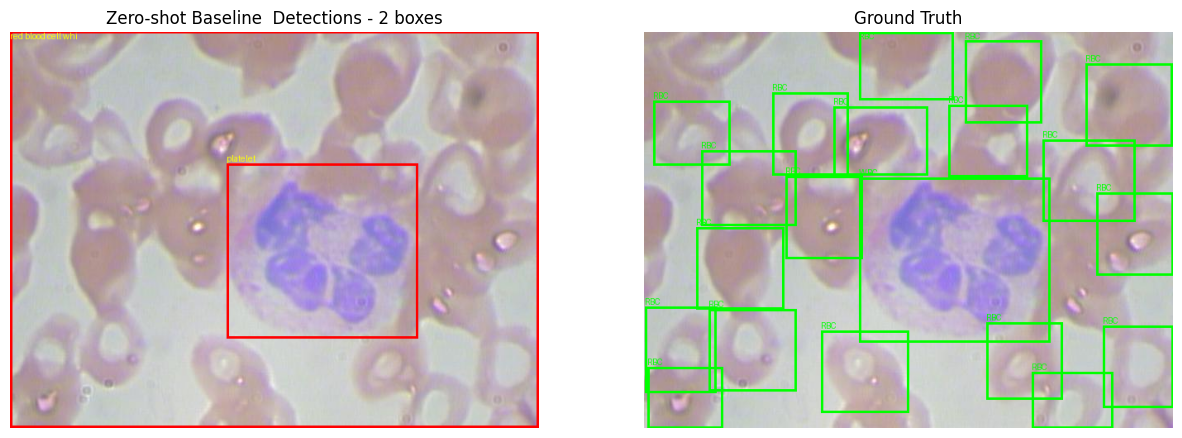

  Visualizing: /content/BCCD_Dataset/BCCD/JPEGImages/BloodImage_00002.jpg


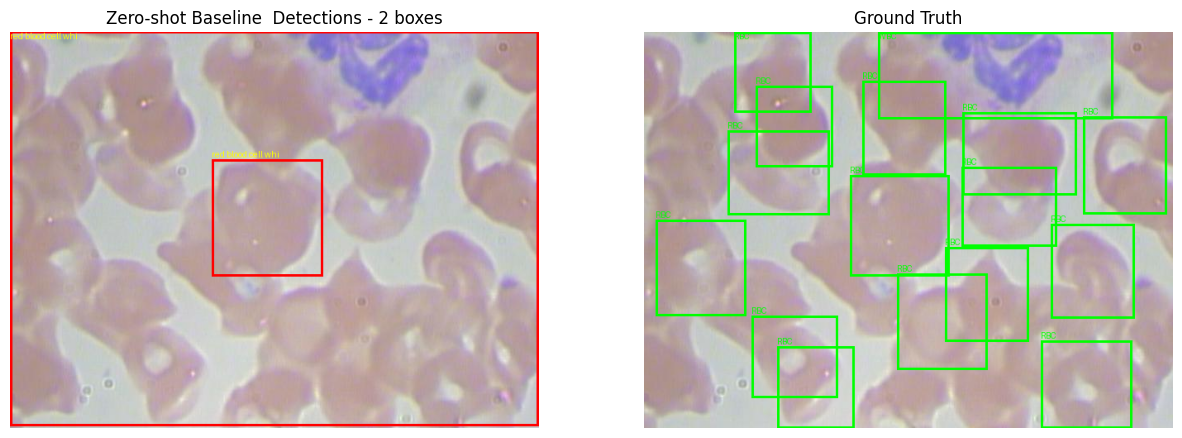


GPU allocated: 0.94 GB


In [ ]:
from eval_per_class import evaluate_per_class, print_comparison
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
import json
import torch

val_coco = json.load(open(paths["val"]))

print("Scoring zero-shot baseline...")
before = evaluate_per_class(model, processor, val_coco, DEVICE,
                            box_thr=0.25, text_thr=0.20)

print()
for k, v in before.items():
    print(f"  {k:<10} F1={v['f1']:.3f}  P={v['precision']:.3f}  "
          f"R={v['recall']:.3f}  (n_gt={v['n_gt']})")

def detect(m, im_path, thr=0.25):
    im  = Image.open(im_path).convert("RGB")
    inp = processor(images=im, text=PROMPT, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        out = m(**inp)
    d = processor.post_process_grounded_object_detection(
        out, inp.input_ids, threshold=thr, text_threshold=0.20,
        target_sizes=[im.size[::-1]])[0]
    return im, d

def visualize_detections(model, processor, coco_data, device, num_images=3, title_prefix=""):
    print(f"\n{title_prefix}Visualizing {num_images} images...")
    cid_name = {c["id"]: c["name"] for c in coco_data["categories"]}
    ann_ids = {ann["image_id"] for ann in coco_data["annotations"]}
    images_with_annotations = [img for img in coco_data["images"] if img["id"] in ann_ids]

    if not images_with_annotations:
        print("No images with annotations found to visualize.")
        return

    for i in range(min(num_images, len(images_with_annotations))):
        img_info  = images_with_annotations[i]
        img_path  = img_info["file_name"]
        print(f"  Visualizing: {img_path}")

        im, d = detect(model, img_path)
        draw = ImageDraw.Draw(im)
        labels = d.get("text_labels", d.get("labels", []))

        for box, lb in zip(d["boxes"].cpu().numpy(), labels):
            draw.rectangle(box.tolist(), outline="red", width=3)
            draw.text((box[0], max(0, box[1] - 12)), str(lb)[:18], fill="yellow")

        gt_img = Image.open(img_path).convert("RGB")
        dg = ImageDraw.Draw(gt_img)
        for ann in coco_data["annotations"]:
            if ann["image_id"] == img_info["id"]:
                x, y, w, h = ann["bbox"]
                dg.rectangle([x, y, x + w, y + h], outline="lime", width=3)
                dg.text((x, max(0, y - 12)), cid_name[ann["category_id"]], fill="lime")

        fig, axes = plt.subplots(1, 2, figsize=(15, 7))
        axes[0].imshow(im); axes[0].axis("off")
        axes[0].set_title(f"{title_prefix} Detections - {len(d['boxes'])} boxes")
        axes[1].imshow(gt_img); axes[1].axis("off")
        axes[1].set_title("Ground Truth")
        plt.show()

visualize_detections(model, processor, val_coco, DEVICE, num_images=2, title_prefix="Zero-shot Baseline ")

import gc
gc.collect(); torch.cuda.empty_cache()
print(f"\nGPU allocated: {torch.cuda.memory_allocated() / 1e9:.2f} GB")

## 8. Import the author's training code

`exec_module` is safe: `main()` sits behind the `__main__` guard, so importing
defines the classes without launching the GUI.

In [ ]:
import importlib.util

spec = importlib.util.spec_from_file_location(
    "gdino_tool", "Video05_finetune_gdino_v2.py")
gdino_tool = importlib.util.module_from_spec(spec)
spec.loader.exec_module(gdino_tool)

GDINODataset      = gdino_tool.GDINODataset
compute_gdino_loss = gdino_tool.compute_gdino_loss
collate_fn        = gdino_tool.collate_fn

train_ds = GDINODataset(paths["train"])
print("train samples:", len(train_ds))
print("prompt:", train_ds.text_prompt)

train samples: 205
prompt: red blood cell . white blood cell . platelet .


In [ ]:
print(train_ds.text_prompt)
print("segments:", len([s for s in train_ds.text_prompt.split(".") if s.strip()]))
assert len([s for s in train_ds.text_prompt.split(".") if s.strip()]) == 3

red blood cell . white blood cell . platelet .
segments: 3


## 9. Fine-tune

**T4 memory notes.** Full fine-tuning of all 230M params does not fit in 14.5 GB:
weights + grads + two AdamW moments alone are ~3.7 GB, and deformable attention
over multi-scale features at 640x480 does the rest. Four things below fix that:

1. `BATCH_SIZE = 1` with gradient accumulation, so the *effective* batch is unchanged.
2. **Backbone and text encoder frozen.** This is the big saving — no grads or
   optimizer state for most of the model. It also prevents the language drift
   that makes the model detect every cell regardless of prompt, so it improves
   results on a 205-image dataset rather than compromising them.
3. Gradient checkpointing — trades ~30% speed for a large activation saving.
4. Mixed precision (fp16) via `torch.amp`.

If it still OOMs, set `USE_CHECKPOINTING = True` and restart the runtime first
(a failed CUDA alloc can leave the session fragmented).

In [ ]:
import torch
from transformers import AutoModelForZeroShotObjectDetection

probe = AutoModelForZeroShotObjectDetection.from_pretrained("gdino_base").to(DEVICE)
probe.eval()
batch = [train_ds[i] for i in range(2)]

with torch.no_grad():
    l32 = compute_gdino_loss(probe, processor, batch, DEVICE)
    with torch.amp.autocast("cuda", dtype=torch.float16):
        l16 = compute_gdino_loss(probe, processor, batch, DEVICE)

print("untrained loss fp32:", l32.item())
print("untrained loss fp16:", l16.item())
print("boxes in batch:", sum(len(s['boxes']) for s in batch))
print("class_labels:", sorted({int(c) for s in batch for c in s['class_ids']}))
del probe; torch.cuda.empty_cache()

Loading weights:   0%|          | 0/1184 [00:00<?, ?it/s]

untrained loss fp32: 268.03887939453125
untrained loss fp16: 268.1908874511719
boxes in batch: 36
class_labels: [1, 2, 3]


In [ ]:
from torch.utils.data import DataLoader
from torch.amp import autocast, GradScaler
import matplotlib.pyplot as plt, gc

EPOCHS       = 8
BATCH_SIZE   = 1      # physical batch
ACCUM_STEPS  = 4      # effective batch = BATCH_SIZE * ACCUM_STEPS
LR           = 1e-5
FREEZE_BACKBONE = True
USE_CHECKPOINTING = False

# --- freeze backbone + text encoder ---------------------------------------
if FREEZE_BACKBONE:
    frozen = trainable = 0
    for name, p in model.named_parameters():
        if name.startswith(("model.backbone", "model.text_backbone")):
            p.requires_grad = False
            frozen += p.numel()
        else:
            trainable += p.numel()
    print(f"frozen {frozen/1e6:.1f}M params, training {trainable/1e6:.1f}M")

if USE_CHECKPOINTING:
    model.gradient_checkpointing_enable()
    print("gradient checkpointing on")

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          collate_fn=collate_fn)
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW(params, lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=LR,
    total_steps=EPOCHS * (len(train_loader) // ACCUM_STEPS + 1), pct_start=0.1)
scaler = GradScaler("cuda")

losses = []
model.train()
for epoch in range(1, EPOCHS + 1):
    running, nsteps = 0.0, 0
    optimizer.zero_grad(set_to_none=True)
    for step, batch in enumerate(train_loader):
        with autocast("cuda", dtype=torch.float16):
            loss = compute_gdino_loss(model, processor, batch, DEVICE)
        scaler.scale(loss / ACCUM_STEPS).backward()

        if (step + 1) % ACCUM_STEPS == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(params, 0.1)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad(set_to_none=True)

        running += loss.item(); nsteps += 1
        del loss
        if step % 40 == 0:
            print(f"  epoch {epoch} step {step}/{len(train_loader)} "
                  f"loss {running/nsteps:.3f} "
                  f"mem {torch.cuda.memory_allocated()/1e9:.1f}GB")
    avg = running / nsteps
    losses.append(avg)
    print(f"epoch {epoch}: mean loss {avg:.4f}")
    gc.collect(); torch.cuda.empty_cache()

plt.figure(figsize=(6, 4))
plt.plot(range(1, EPOCHS + 1), losses, marker="o")
plt.xlabel("epoch"); plt.ylabel("mean loss"); plt.grid(alpha=.3)
plt.title("training loss"); plt.show()

if USE_CHECKPOINTING:
    model.gradient_checkpointing_disable()   # must be off for inference
model.save_pretrained("gdino_bccd_finetuned")
processor.save_pretrained("gdino_bccd_finetuned")
print("checkpoint saved")

frozen 195.8M params, training 36.5M
  epoch 1 step 0/205 loss 2666.373 mem 1.2GB


/tmp/ipykernel_5893/2706291985.py:51: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


  epoch 1 step 40/205 loss 5914.563 mem 1.5GB
  epoch 1 step 80/205 loss 6008.844 mem 1.5GB
  epoch 1 step 120/205 loss 4859.375 mem 1.5GB
  epoch 1 step 160/205 loss 3991.367 mem 1.5GB
  epoch 1 step 200/205 loss 3376.736 mem 1.5GB
epoch 1: mean loss 3331.1601
  epoch 2 step 0/205 loss 434.083 mem 1.5GB
  epoch 2 step 40/205 loss 5186.661 mem 1.5GB
  epoch 2 step 80/205 loss 3812.291 mem 1.5GB
  epoch 2 step 120/205 loss 3106.611 mem 1.5GB
  epoch 2 step 160/205 loss 3785.825 mem 1.5GB
  epoch 2 step 200/205 loss 3204.727 mem 1.5GB
epoch 2: mean loss 3172.7948
  epoch 3 step 0/205 loss 304.780 mem 1.5GB
  epoch 3 step 40/205 loss 4458.522 mem 1.5GB
  epoch 3 step 80/205 loss 2793.290 mem 1.5GB
  epoch 3 step 120/205 loss 2783.014 mem 1.5GB
  epoch 3 step 160/205 loss 2549.253 mem 1.5GB
  epoch 3 step 200/205 loss 2930.932 mem 1.5GB
epoch 3: mean loss 2889.5524
  epoch 4 step 0/205 loss 613.731 mem 1.5GB
  epoch 4 step 40/205 loss 735.185 mem 1.5GB
  epoch 4 step 80/205 loss 4456.595 m

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

checkpoint saved


## 10. After — identical metric, threshold, and prompt

Any of those three differing between runs would make the comparison measure
the change rather than the fine-tuning.

In [ ]:
print("Scoring fine-tuned model...")
after = evaluate_per_class(model, processor, val_coco, DEVICE,
                           box_thr=0.25, text_thr=0.20)

print_comparison(before, after)

Scoring fine-tuned model...
    20/87 images
    40/87 images
    60/87 images
    80/87 images
    note: 1 predictions had labels matching no phrase

class         n_gt  F1 before  F1 after    delta  P after  R after
------------------------------------------------------------------
RBC            967      0.064     0.664   +0.600    0.516    0.931
WBC             87      0.274     0.820   +0.545    0.712    0.966
Platelets       83      0.305     0.533   +0.228    0.385    0.867
------------------------------------------------------------------
macro F1                0.215     0.672   +0.458

(macro = unweighted class mean, so platelets count as much as RBC)


## 11. Visual check

Numbers move for boring reasons. Look at the boxes before believing the table.
Green is ground truth.

Visualizing comparison for: /content/BCCD_Dataset/BCCD/JPEGImages/BloodImage_00007.jpg


Loading weights:   0%|          | 0/1184 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/transformers/models/grounding_dino/processing_grounding_dino.py:94: FutureWarning: The key `labels` is will return integer ids in `GroundingDinoProcessor.post_process_grounded_object_detection` output since v4.51.0. Use `text_labels` instead to retrieve string object names.
  warnings.warn(self.message, FutureWarning)


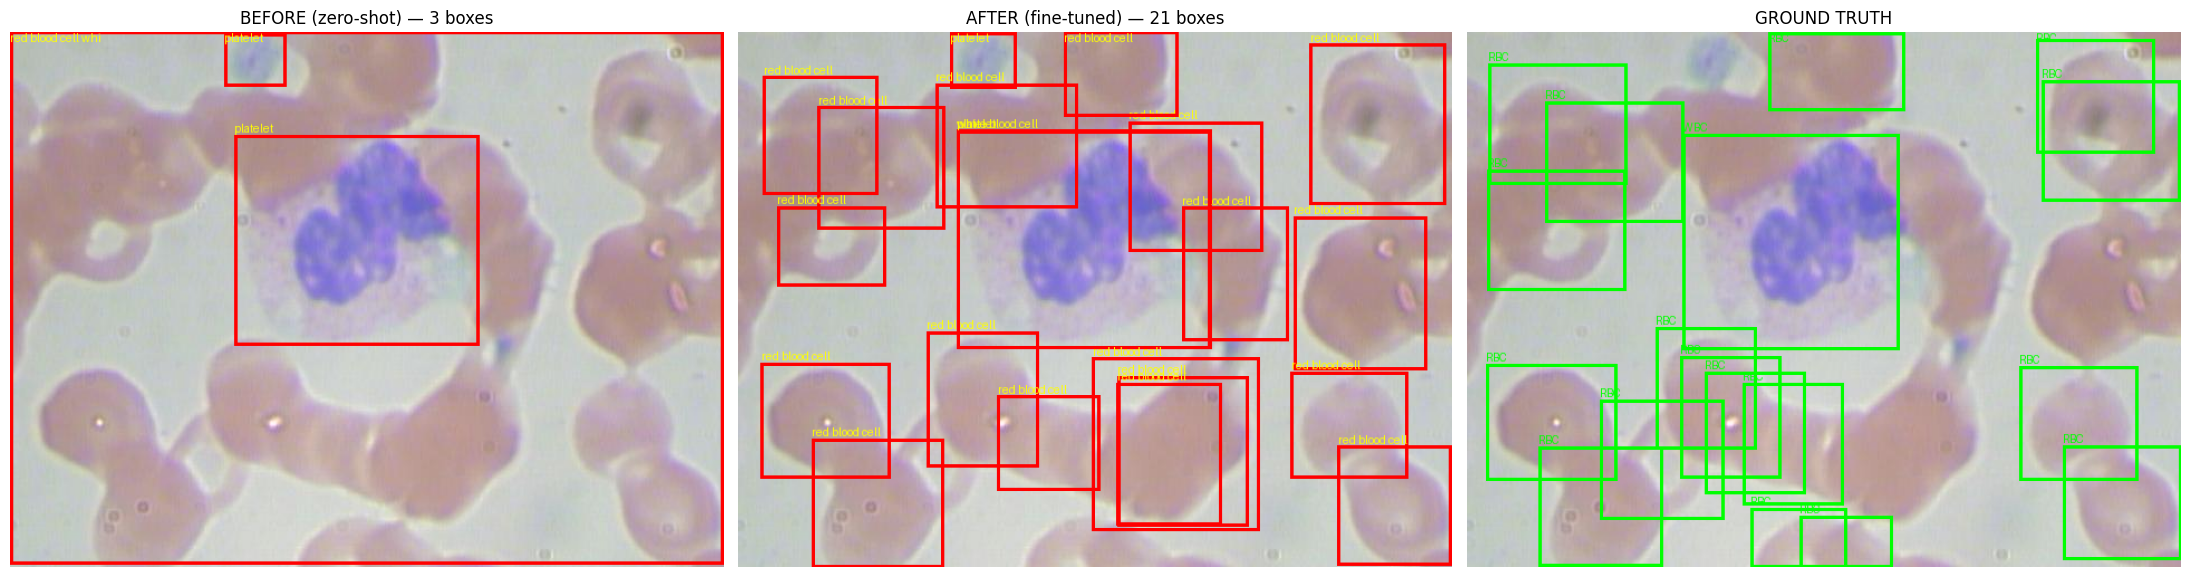

In [ ]:
%matplotlib inline
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
import gc
import json
import torch
from transformers import AutoModelForZeroShotObjectDetection

def run_viz():
    plt.close('all')
    test_coco = json.load(open(paths["test"]))
    img_info  = test_coco["images"][0]
    img_path  = img_info["file_name"]

    def detect(m, path, thr=0.25):
        im  = Image.open(path).convert("RGB")
        inp = processor(images=im, text=PROMPT, return_tensors="pt").to(DEVICE)
        with torch.no_grad():
            out = m(**inp)
        d = processor.post_process_grounded_object_detection(
            out, inp.input_ids, threshold=thr, text_threshold=0.20,
            target_sizes=[im.size[::-1]])[0]
        return im, d

    print(f"Visualizing comparison for: {img_path}")
    gc.collect(); torch.cuda.empty_cache()
    base_model = AutoModelForZeroShotObjectDetection.from_pretrained(
        "gdino_base").to(DEVICE).eval()

    fig, axes = plt.subplots(1, 3, figsize=(22, 7))
    for ax, (m, title) in zip(axes[:2], [(base_model, "BEFORE (zero-shot)"),
                                         (model, "AFTER (fine-tuned)")]):
        im, d = detect(m, img_path)
        draw = ImageDraw.Draw(im)
        labels = d.get("text_labels", d.get("labels", []))
        for box, lb in zip(d["boxes"].cpu().numpy(), labels):
            draw.rectangle(box.tolist(), outline="red", width=3)
            draw.text((box[0], max(0, box[1] - 12)), str(lb)[:18], fill="yellow")
        ax.imshow(im); ax.axis("off")
        ax.set_title(f"{title} — {len(d['boxes'])} boxes")

    gt = Image.open(img_path).convert("RGB")
    dg = ImageDraw.Draw(gt)
    cid_name = {c["id"]: c["name"] for c in test_coco["categories"]}
    for a in test_coco["annotations"]:
        if a["image_id"] == img_info["id"]:
            x, y, w, h = a["bbox"]
            dg.rectangle([x, y, x + w, y + h], outline="lime", width=3)
            dg.text((x, max(0, y - 12)), cid_name[a["category_id"]], fill="lime")
    axes[2].imshow(gt); axes[2].axis("off")
    axes[2].set_title("GROUND TRUTH")

    plt.tight_layout()
    del base_model
    torch.cuda.empty_cache()
    return fig

run_viz()

## 12. Final test score — run once

Everything above was measured on validation. If you tuned epochs, learning
rate, or thresholds against validation and then reported validation, that
number is optimistic. Run this **once**, when you have stopped changing
things.

In [ ]:
test_coco = json.load(open(paths["test"]))

print("Scoring on held-out test split...")
test_after = evaluate_per_class(model, processor, test_coco, DEVICE,
                                box_thr=0.25, text_thr=0.20)
print()
for k, v in test_after.items():
    print(f"  {k:<10} F1={v['f1']:.3f}  P={v['precision']:.3f}  "
          f"R={v['recall']:.3f}  (n_gt={v['n_gt']})")

Scoring on held-out test split...
    20/72 images
    40/72 images
    60/72 images
    note: 1 predictions had labels matching no phrase

  RBC        F1=0.676  P=0.533  R=0.924  (n_gt=805)
  WBC        F1=0.798  P=0.676  R=0.972  (n_gt=71)
  Platelets  F1=0.537  P=0.383  R=0.899  (n_gt=69)


## 13. Optional — download the checkpoint

The fine-tuned model is a few GB and Colab wipes it when the session ends.

In [ ]:
!zip -qr gdino_bccd_finetuned.zip gdino_bccd_finetuned
from google.colab import files
files.download("gdino_bccd_finetuned.zip")

/usr/local/lib/python3.13/dist-packages/transformers/models/grounding_dino/processing_grounding_dino.py:89: FutureWarning: The key `labels` is will return integer ids in `GroundingDinoProcessor.post_process_grounded_object_detection` output since v4.51.0. Use `text_labels` instead to retrieve string object names.
  warnings.warn(self.message, FutureWarning)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

/usr/local/lib/python3.13/dist-packages/transformers/models/grounding_dino/processing_grounding_dino.py:89: FutureWarning: The key `labels` is will return integer ids in `GroundingDinoProcessor.post_process_grounded_object_detection` output since v4.51.0. Use `text_labels` instead to retrieve string object names.
  warnings.warn(self.message, FutureWarning)
/usr/local/lib/python3.13/dist-packages/transformers/models/grounding_dino/processing_grounding_dino.py:89: FutureWarning: The key `labels` is will return integer ids in `GroundingDinoProcessor.post_process_grounded_object_detection` output since v4.51.0. Use `text_labels` instead to retrieve string object names.
  warnings.warn(self.message, FutureWarning)
